# Parcial 2 — Análisis de datos de Joomla en PostgreSQL

**Autores:** Samuel Arevalo, Juan Pablo Novoa y Miguel Gordillo

Este notebook se conecta al contenedor **`database`** (PostgreSQL 16) a través de la red
`backend_net`, usando el DNS embebido de Docker (`database` → IP del contenedor).

Pasos:
1. Conexión con **SQLAlchemy + psycopg2** usando las variables de entorno del `.env`.
2. Inventario de tablas de Joomla (filas y tamaño en disco).
3. Consulta de usuarios y logs de acciones.
4. Gráficos con **matplotlib / pandas**.

In [1]:
# 1) Dependencias (ya instaladas al arrancar el contenedor; esto es solo respaldo)
import importlib, subprocess, sys
for pkg, mod in [("psycopg2-binary", "psycopg2"), ("sqlalchemy", "sqlalchemy"),
                 ("pandas", "pandas"), ("matplotlib", "matplotlib")]:
    try:
        importlib.import_module(mod)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", pkg])

import os
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, text
%matplotlib inline

In [2]:
# 2) Conexión a PostgreSQL (servicio "database" en backend_net)
DB_USER = os.getenv("POSTGRES_USER", "joomlauser")
DB_PASS = os.getenv("POSTGRES_PASSWORD", "joomlapassword")
DB_HOST = os.getenv("POSTGRES_HOST", "database")
DB_PORT = os.getenv("POSTGRES_PORT", "5432")
DB_NAME = os.getenv("POSTGRES_DB", "joomladb")
PREFIX  = os.getenv("JOOMLA_DB_PREFIX", "jos_")

engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}",
    pool_size=5, pool_pre_ping=True,   # connection pooling (Capa 4/7)
)

with engine.connect() as conn:
    version = conn.execute(text("SELECT version()")).scalar()
    addr = conn.execute(text("SELECT inet_server_addr()::text, inet_server_port(), inet_client_addr()::text")).one()

print("Conectado a:", version)
print(f"Servidor PostgreSQL -> {addr[0]}:{addr[1]}  |  Cliente (jupyter) -> {addr[2]}")

Conectado a: PostgreSQL 16.15 on x86_64-pc-linux-musl, compiled by gcc (Alpine 15.2.0) 15.2.0, 64-bit
Servidor PostgreSQL -> 172.28.2.30/32:5432  |  Cliente (jupyter) -> 172.28.2.40/32


In [3]:
# 3) Inventario de tablas: filas vivas y tamaño en disco
tablas = pd.read_sql(text("""
    SELECT relname                               AS tabla,
           n_live_tup                            AS filas,
           pg_total_relation_size(relid)         AS bytes,
           n_tup_ins                             AS insertadas,
           n_tup_upd                             AS actualizadas
    FROM pg_stat_user_tables
    ORDER BY pg_total_relation_size(relid) DESC
"""), engine)

tablas["kB"] = (tablas["bytes"] / 1024).round(1)
joomla = tablas[tablas["tabla"].str.startswith(PREFIX)]
print(f"Tablas totales: {len(tablas)}  |  Tablas de Joomla ({PREFIX}*): {len(joomla)}")
tablas.head(15)

Tablas totales: 76  |  Tablas de Joomla (jos_*): 76


,tabla,filas,bytes,insertadas,actualizadas,kB
0,jos_session,15,335872,995,1196,328.0
1,jos_extensions,251,319488,251,254,312.0
2,jos_guidedtour_steps,117,221184,117,234,216.0
3,jos_workflows,1,180224,1,2,176.0
4,jos_scheduler_tasks,3,163840,3,7,160.0
5,jos_finder_taxonomy,1,163840,1,0,160.0
6,jos_categories,6,147456,6,12,144.0
7,jos_menu,22,147456,22,0,144.0
8,jos_tags,1,147456,1,2,144.0
9,jos_tuf_metadata,1,147456,1,5,144.0


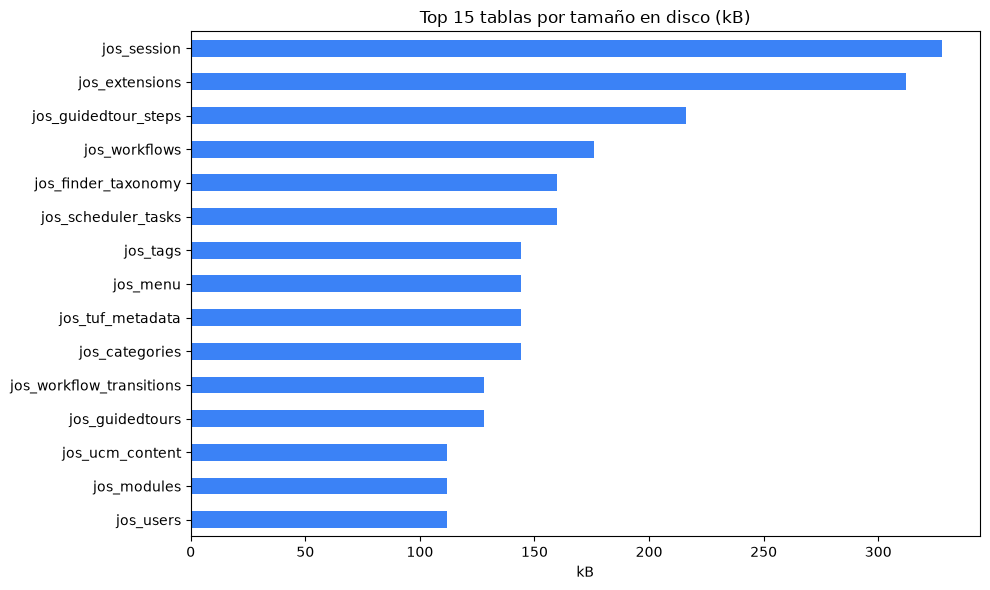

In [4]:
# 4) Gráfico 1: las 15 tablas más grandes
top = tablas.head(15).sort_values("kB")
if top.empty:
    print("Aún no hay tablas (¿Joomla sigue instalándose?). Vuelve a ejecutar en unos segundos.")
else:
    ax = top.plot.barh(x="tabla", y="kB", figsize=(10, 6), color="#3b82f6", legend=False)
    ax.set_title("Top 15 tablas por tamaño en disco (kB)")
    ax.set_xlabel("kB"); ax.set_ylabel("")
    plt.tight_layout()
    plt.savefig("top_tablas.png", dpi=110)
    plt.show()

In [5]:
# 5) Usuarios y logs de acciones de Joomla
def tabla_existe(nombre):
    with engine.connect() as conn:
        return conn.execute(text("SELECT to_regclass(:t) IS NOT NULL"), {"t": f"public.{nombre}"}).scalar()

if tabla_existe(f"{PREFIX}users"):
    usuarios = pd.read_sql(text(f'SELECT id, name, username, email, "registerDate" FROM {PREFIX}users'), engine)
    display(usuarios)
else:
    print("Tabla de usuarios no encontrada todavía.")

if tabla_existe(f"{PREFIX}action_logs"):
    logs = pd.read_sql(text(f"""
        SELECT log_date, extension, message_language_key AS evento, ip_address
        FROM {PREFIX}action_logs ORDER BY log_date DESC LIMIT 20"""), engine)
    print(f"Registros de action_logs: {len(logs)}")
    display(logs)

,id,name,username,email,registerDate
0,338,Administrador,admin,admin@parcial2.local,2026-10-02 02:59:58


Registros de action_logs: 16


,log_date,extension,evento,ip_address
0,2026-10-03 16:36:59,com_guidedtours.state,PLG_ACTIONLOG_JOOMLA_GUIDEDTOURS_TOURDELAYED,COM_ACTIONLOGS_DISABLED
1,2026-10-03 16:36:57,com_users,PLG_ACTIONLOG_JOOMLA_USER_LOGGED_IN,COM_ACTIONLOGS_DISABLED
2,2026-10-03 15:00:48,com_guidedtours.state,PLG_ACTIONLOG_JOOMLA_GUIDEDTOURS_TOURDELAYED,COM_ACTIONLOGS_DISABLED
3,2026-10-03 15:00:45,com_users,PLG_ACTIONLOG_JOOMLA_USER_LOGGED_IN,COM_ACTIONLOGS_DISABLED
4,2026-10-03 01:02:41,com_guidedtours.state,PLG_ACTIONLOG_JOOMLA_GUIDEDTOURS_TOURDELAYED,COM_ACTIONLOGS_DISABLED
5,2026-10-03 01:02:36,com_users,PLG_ACTIONLOG_JOOMLA_USER_LOGGED_IN,COM_ACTIONLOGS_DISABLED
6,2026-10-02 16:30:21,com_guidedtours.state,PLG_ACTIONLOG_JOOMLA_GUIDEDTOURS_TOURDELAYED,COM_ACTIONLOGS_DISABLED
7,2026-10-02 16:30:14,com_users,PLG_ACTIONLOG_JOOMLA_USER_LOGGED_IN,COM_ACTIONLOGS_DISABLED
8,2026-10-02 16:26:12,com_users,PLG_ACTIONLOG_JOOMLA_USER_LOGGED_IN,COM_ACTIONLOGS_DISABLED
9,2026-10-02 16:03:36,com_users,PLG_ACTIONLOG_JOOMLA_USER_LOGGED_OUT,COM_ACTIONLOGS_DISABLED


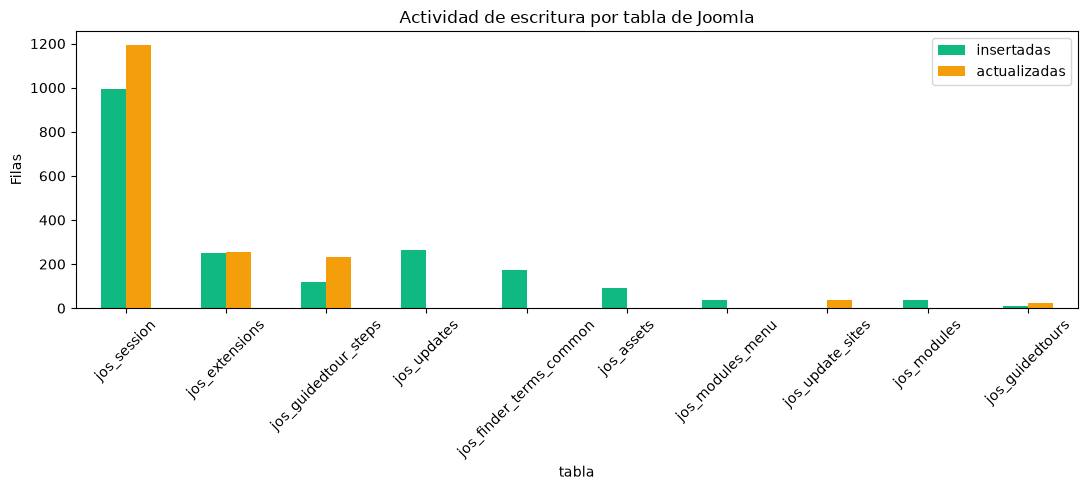

In [6]:
# 6) Gráfico 2: actividad de escritura (insertadas vs actualizadas) en tablas de Joomla
act = (joomla.assign(total=joomla["insertadas"] + joomla["actualizadas"])
             .query("total > 0")
             .sort_values("total", ascending=False)
             .head(10))
if act.empty:
    print("Sin actividad de escritura registrada todavía.")
else:
    ax = act.plot.bar(x="tabla", y=["insertadas", "actualizadas"], figsize=(11, 5),
                      color=["#10b981", "#f59e0b"], rot=45)
    ax.set_title("Actividad de escritura por tabla de Joomla")
    ax.set_ylabel("Filas")
    plt.tight_layout()
    plt.show()

In [7]:
# 7) Estadísticas globales de la base de datos
stats = pd.read_sql(text("""
    SELECT datname, numbackends AS conexiones, xact_commit, xact_rollback,
           blks_read, blks_hit,
           round(100.0 * blks_hit / NULLIF(blks_hit + blks_read, 0), 2) AS cache_hit_pct
    FROM pg_stat_database WHERE datname = current_database()
"""), engine)
stats

,datname,conexiones,xact_commit,xact_rollback,blks_read,blks_hit,cache_hit_pct
0,joomladb,1,49560,12,4210,3652083,99.88
